# Spotify RecSystem End to End (Sistema de recomendação spotify de ponta a ponta)
**[EN-US]**

Recommendation system, which recommends songs from Spotify. Created end-to-end, i.e. connecting and authorizing with the API, extracting data from the API, performing exploratory analysis, creating the model and producing the model.

**[PT-BR]**

Sistema de recomendação, que recomenda músicas do spotify. Criado de ponta a ponta, ou seja, a conexão e autorização com a API, extração dos dados da API, realização da anaálise exploratória, criação do modelo e produção do modelo.

## Table of Contents
* [Packages](#Packages-(Pacotes))
* [Environment Variables](#Environment-Variables-(Variáveis-de-Ambiente))
* [Utils Functions](#Utils-Functions-(Funções-Úteis))
    * [Ingestion Functions](#Ingestion-Functions-(Funções-de-Ingestão))
        * [Request Authorization](#Request-Authorization-(Requisitando-a-Autorização))
        * [Playlist Extraction](#Playlist-Extraction-(Extração-da-Playlist))
        * [Track Features Extraction](#Track-Features-Extraction-(Extração-das-Features-da-Track))
        * [Playlist to DataFrame](#Playlist-to-DataFrame-(Playlist-para-DataFrame))
* [EDA (Exploratory Data Analysis)](#EDA-(Exploratory-Data-Analysis))
    * [Playlists](#Playlists)

## Packages (Pacotes)
**[EN-US]**
* [os](https://docs.python.org/3/library/os.html): built-in module, provides a portable way of using operating system dependent functionality.
* [requests](https://pypi.org/project/requests/): is a simple HTTP library, for making HTTP requests.
* [base64](https://docs.python.org/pt-br/3.7/library/base64.html): provides functions for encoding binary data to printable ASCII characters and decoding such encodings back to binary data.
* [dotenv](https://pypi.org/project/python-dotenv/): reads key-value pairs from a .env file and can set them as environment variables.
* [pandas](https://pandas.pydata.org/): is the main package for data manipulation.
* [numpy](www.numpy.org): is the main package for scientific computing.
* [matplotlib](http://matplotlib.org): is a library to plot graphs.

**[PT-BR]**
* [os](https://docs.python.org/3/library/os.html): módulo integrado, fornece uma maneira portátil de usar funcionalidades dependentes do sistema operacional.
* [requests](https://pypi.org/project/requests/): é uma biblioteca HTTP simples, para fazer solicitações HTTP.
* [base64](https://docs.python.org/pt-br/3.7/library/base64.html): fornece funções para codificar dados binários em caracteres ASCII imprimíveis e decodificar essas codificações de volta para dados binários.
* [dotenv](https://pypi.org/project/python-dotenv/): lê pares de chave-valor de um arquivo .env e pode defini-los como variáveis de ambiente.
* [pandas](https://pandas.pydata.org/): é o principal pacote para manipulação de dados.
* [numpy](www.numpy.org): é o principal pacote para computação científica.
* [matplotlib](http://matplotlib.org): é uma biblioteca para plotar gráficos.

In [1]:
import os
from requests import post, get
from base64 import b64encode
from dotenv import load_dotenv
load_dotenv() # take environment variables from (acessa as variáveis de ambiente)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (5.0, 4.0) # set default size of plots (definindo o tamanho padrão dos plots)

## Environment Variables (Variáveis de Ambiente)
**[EN-US]**

Setting the environment variables:
* `client_id`: the client ID generated after registering your application.
* `client_secret`: the client secret generated after registering your application.

**[PT-BR]**

Definindo as variáveis de ambiente:
* `client_id`: o cliente ID gerado após registrar seu aplicativo.
* `client_secret`: o client secret gerado após o registro do seu aplicativo.

In [2]:
client_id = os.environ['CLIENT_ID_SPOTIFY']
client_secret = os.environ['CLIENT_SECRET_SPOTIFY']

## Utils Functions (Funções Úteis)
**[EN-US]**

Various useful functions used in this system.

**[PT-BR]**

Várias funções úteis utilizadas nesse sistema.

### Ingestion Functions (Funções de Ingestão)
**[EN-US]**

The `request_auth` function to request authorization from Spotify, the `get_playlist` function to extract tracks from a playlist and the `track_features` function to extract the features of these tracks. After that, the `playlist_to_dataframe` function transforms the data into JSON for a pandas DataFrame.

**[PT-BR]**

Função `request_auth` para requisitar a autorização ao spotify, função `get_playlist` para extrair as tracks de uma playlist e a função `track_features` para extrair as features dessas tracks. Após isso, a função `playlist_to_dataframe` transforma os dados em JSON para um DataFrame pandas.

#### Request Authorization (Requisitando a Autorização)
**[EN-US]**

The first step is to send a POST request to the `/api/token` endpoint of the Spotify OAuth 2.0 Service. If everything goes well, you'll receive a response with a 200 OK status and the JSON data.

**[PT-BR]**

A primeira etapa é enviar uma solicitação POST para o endpoint `/api/token` do serviço Spotify OAuth 2.0. Se tudo correr bem, você receberá uma resposta com o status 200 OK e os dados JSON.

In [3]:
def request_auth(client_id, client_secret):
    """
    [EN-US]
    The first step is to send a POST request to the /api/token endpoint of the Spotify OAuth 2.0 Service.
    If everything goes well, you'll receive a response with a 200 OK status and the JSON data.
    
    [PT-BR]
    A primeira etapa é enviar uma solicitação POST para o endpoint /api/token do serviço Spotify OAuth 2.0.
    Se tudo correr bem, você receberá uma resposta com o status 200 OK e os dados JSON.
    
    Argument:
    client_id -- The client ID generated after registering your application.
                 (O cliente ID gerado após registrar seu aplicativo.)
    client_secret -- the client secret generated after registering your application.
                     (O client secret gerado após o registro do seu aplicativo.)
    
    Returns:
    access_token -- An access token that can be provided in subsequent calls, for example to Spotify Web API services.
                    (Um token de acesso que pode ser fornecido em chamadas subsequentes, por exemplo, para serviços Spotify Web API.)
    token_type -- How the access token may be used: always "Bearer".
                  (Como o token de acesso pode ser utilizado: sempre “Bearer”.)
    token_expires -- The time period (in seconds) for which the access token is valid.
                     (O período de tempo (em segundos) durante o qual o token de acesso é válido.)
    """
    # Base 64 encoded string that contains the client ID and client secret key (String codificada em base 64 que contém o clinet ID e a client secret key)
    b64_encoded = b64encode(f'{client_id}:{client_secret}'.encode())
    auth_b64 = str(b64_encoded, 'utf-8')
    # Setting options for authorization (Definindo as opções para a autorização)
    base_url = 'https://accounts.spotify.com/api/token'    
    
    auth_options = {
        'url': base_url,
        'headers':{
            'Authorization': 'Basic ' + auth_b64,
            'content-type': 'application/x-www-form-urlencoded'
        },
        'form':{
            'grant_type': 'client_credentials'
        },
        'json': True
    }

    # Send a post request (Enviando a requisição post)
    request = post(url=auth_options['url'], headers=auth_options['headers'], data=auth_options['form'])
    # If the request status code is 200 (Caso o status code da requisição for 200)
    if request.status_code == 200:
        json_request = request.json()
        access_token = json_request['access_token']
        token_type = json_request['token_type']
        token_expires = json_request['expires_in']
        print('Acesso autorizado e dados extraídos!')
    else:
        print('Acesso não autorizado!')
        
    return access_token, token_type, token_expires

#### Playlist Extraction (Extração da Playlist)
**[EN-US]**

Get full details of the items of a playlist owned by a Spotify user.

**[PT-BR]**

Obtenha detalhes completos dos itens de uma playlist de um usuário do Spotify.

In [4]:
def get_playlist(playlist, token_type, access_token, offset=0, limit=100):
    """
    [EN-US]
    Get full details of the items of a playlist owned by a Spotify user.
    
    [PT-BR]
    Obtenha detalhes completos dos itens de uma playlist de propriedade de um usuário do Spotify.
    
    Argument:
    playlist -- The Spotify URL of the playlist.
                (O URL do Spotify da playlist.)
    token_type -- How the access token may be used: always "Bearer".
                  (Como o token de acesso pode ser utilizado: sempre “Bearer”.)
    access_token -- An access token that can be provided in subsequent calls, for example to Spotify Web API services.
                    (Um token de acesso que pode ser fornecido em chamadas subsequentes, por exemplo, para serviços Spotify Web API.)
    offset -- The index of the first item to return. Default: 0 (the first item). Use with limit to get the next set of items.
              (O índice do primeiro item a ser retornado. Padrão: 0 (o primeiro item). Use com limit para obter o próximo conjunto de itens.)
    limit -- The maximum number of items to return. Default: 100. Minimum: 1. Maximum: 100.
             (O número máximo de itens a serem retornados. Padrão: 100. Mínimo: 1. Máximo: 100.)
    
    Returns:
    response.json() -- pages of tracks in JSON.
                       (páginas de tracks em JSON.)
    """
    # Turning the Spotify playlist URL into just the Playlist ID to send the get request (Transformando o Spotify URL da playlist apenas no Playlist ID para enviar a requisição get)
    playlist_id = playlist.split('/')[-1].split('?')[0]
    # Setting options for the request (Definindo as opções para a requisição)
    endpoint = f'https://api.spotify.com/v1/playlists/{playlist_id}/tracks?offset={str(offset)}&limit={str(limit)}'
    headers={
        'Authorization': token_type + ' ' + access_token
    }

    # Send a get request (Enviando a requisição get)
    response = get(url=endpoint, headers=headers)
    # If the request status code is not 200 (Caso o status code da requisição não seja 200)
    if response.status_code != 200:
        print('Error! Dados não extraídos')

    return response.json()

#### Track Features Extraction (Extração das Features da Track)
**[EN-US]**

Get audio feature information for a single track identified by its unique Spotify ID.

**[PT-BR]**

Obtenha informações sobre recursos de áudio de uma única faixa identificada por seu ID exclusivo do Spotify.

In [5]:
def track_features(track_id, token_type, access_token):
    """
    [EN=US]
    Get audio feature information for a single track identified by its unique Spotify ID.
    
    [PT-BR]
    Obtenha informações sobre recursos de áudio de uma única faixa identificada por seu ID exclusivo do Spotify.
    
    Argument:
    track_id -- The Spotify ID for the track.
                (O ID do Spotify para a track.)
    token_type -- How the access token may be used: always "Bearer".
                  (Como o token de acesso pode ser utilizado: sempre “Bearer”.)
    access_token -- An access token that can be provided in subsequent calls, for example to Spotify Web API services.
                    (Um token de acesso que pode ser fornecido em chamadas subsequentes, por exemplo, para serviços Spotify Web API.)
    
    Returns:
    response.json() -- Audio features for one track in JSON.
                       (Features de áudio para uma track em JSON.)
    """
    # Setting options for the request (Definindo as opções para a requisição)
    endpoint = f'https://api.spotify.com/v1/audio-features/{track_id}'
    headers={
        'Authorization': token_type + ' ' + access_token
    }
    
    # Send a get request (Enviando a requisição get)
    response = get(url=endpoint, headers=headers)
    # If the request status code is not 200 (Caso o status code da requisição não seja 200)
    if response.status_code != 200:
        print('Error! Dados não extraídos')

    return response.json()

#### Playlist to DataFrame (Playlist para DataFrame)
**[EN-US]**

Input's a playlist URL and returns a pandas DataFrame.

**[PT-BR]**

A entrada é um URL de lista de reprodução e retorna um DataFrame do pandas.

In [6]:
def playlist_to_dataframe(playlist_endpoint, token_type, access_token, offset=0, limit=100, label=None):
    """
    [EN=US]
    Input's a playlist URL and returns a pandas DataFrame.
    
    [PT-BR]
    A entrada é um URL de lista de reprodução e retorna um DataFrame do pandas.
    
    Argument:
    playlist_endpoint -- The Spotify URL of the playlist.
                         (O URL do Spotify da playlist.)
    token_type -- How the access token may be used: always "Bearer".
                  (Como o token de acesso pode ser utilizado: sempre “Bearer”.)
    access_token -- An access token that can be provided in subsequent calls, for example to Spotify Web API services.
                    (Um token de acesso que pode ser fornecido em chamadas subsequentes, por exemplo, para serviços Spotify Web API.)
    offset -- The index of the first item to return. Default: 0 (the first item). Use with limit to get the next set of items.
              (O índice do primeiro item a ser retornado. Padrão: 0 (o primeiro item). Use com limit para obter o próximo conjunto de itens.)
    limit -- The maximum number of items to return. Default: 100. Minimum: 1. Maximum: 100.
             (O número máximo de itens a serem retornados. Padrão: 100. Mínimo: 1. Máximo: 100.)
    label -- The label that the playlist will be classified by. Default: None. Label 1 for good playlist and 0 for bad playlist.
             (O label que a playlist será classificada. Padrão: None. Label 1 para playlist boa e 0 para playlist ruim.)
    
    Returns:
    df -- Pandas DataFrame with all tracks and the features of each track in the playlist.
          (DataFrame pandas com todas as tracks e as features de cada track da playlist.)
    """
    # Final list that will be transformed into DataFrame (Lista final que será transformada em DataFrame)
    examples = []
    # Tracks in JSON (Tracks em JSON)
    playlist = get_playlist(playlist=playlist_endpoint, token_type=token_type, access_token=access_token, offset=offset, limit=limit)
    
    # For loop through all playlist pages (Percorrendo todas as páginas da playlist)
    for page in range(offset, playlist['total'] + 1, limit):
        # Example size on page (Tamanho de exemplo na página)
        m = len(playlist['items'])
        # For loop through each example and adding the data to the final list (Percorrendo cada exemplo e adicionando os dados à lista final)
        for i in range(m):
            # Accessing each track (Acessando cada track)
            track = playlist['items'][i]['track']
            # Track features in JSON (Features da track em JSON)
            track_feature = track_features(track['id'], token_type, access_token)


            # Intermediate list for append each m example (Lista intermediária para adicionar cada exemplo m)
            example = [
                track['id'],
                track['name'],
                track['artists'][0]['name'],
                track['duration_ms'],
                track['popularity'],
                track_feature['danceability'],
                track_feature['energy'],
                track_feature['key'],
                track_feature['loudness'],
                track_feature['mode'],
                track_feature['speechiness'],
                track_feature['acousticness'],
                track_feature['instrumentalness'],
                track_feature['liveness'],
                track_feature['valence'],
                track_feature['tempo']
            ]

            # Adding to final list (Adicionando à lista final)
            examples.append(example)
        # If the page has more than 100 examples, you will read the next page (Se a página tiver mais de 100 exemplos, lerá a próxima página)
        if m >= 100:
            # JSON tracks of the next offset (Tracks em JSON do próximo offset)
            playlist = get_playlist(playlist=playlist_endpoint, token_type=token_type, access_token=access_token, offset=page + limit, limit=limit)
    
    # DataFrame's columns names (Nomes das colunas do DataFrame)
    features = ['id', 'name', 'artists', 'duration_ms', 'popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
               'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
    # Transforming into DataFrame (Transformando em DataFrame)
    df = pd.DataFrame(examples, columns=features)
    
    # Setting the labels (Definindo os labels)
    if label == 0:
        df['y'] = 0
    elif label == 1:
        df['y'] = 1
    
    return df

## EDA (Exploratory Data Analysis)
**[EN-US]**

Exploratory Data Analysis

**[PT-BR]**

Análise de Dados Exploratória

In [7]:
access_token, token_type, token_expires = request_auth(client_id=client_id, client_secret=client_secret)

Acesso autorizado e dados extraídos!


Playlists

In [8]:
good_songs = 'https://open.spotify.com/playlist/6DI0NiX9bE3fIF6cEoI2zL?si=ef8a610d53f64627'
bad_songs = 'https://open.spotify.com/playlist/6IBody2iNg5TgmAeYiHYpW?si=xsEvNjbbQYqt0rs9wP3yOg'

In [ ]:
df_good = playlist_to_dataframe(good_songs, token_type, access_token, offset=0, limit=100, label=1)
df_good.head()

In [48]:
print(f'Total de tracks na playlist: {df_good.shape[0]}')

Total de tracks na playlist: 614


In [19]:
df_good.to_csv('./data/df_good.csv')

In [20]:
df_good['artists'].value_counts().sort_values(ascending=False)

artists
Iron Maiden           40
System Of A Down      34
Alanis Morissette     14
Mamonas Assassinas    13
Phoenix               12
                      ..
Anna Kendrick          1
CNCO                   1
Us The Duo             1
Man Man                1
Tom Speight            1
Name: count, Length: 290, dtype: int64

In [21]:
print(f'Duração média: {np.mean(df_good["duration_ms"]) / 60:.2f}min\nPopularidade média: {np.mean(df_good["popularity"]):.1f}')

Duração média: 3895.69min
Popularidade média: 40.9


### Bad Songs

In [ ]:
df_bad = playlist_to_dataframe(bad_songs, token_type, access_token, offset=0, limit=100, label=0)
df_bad.head()

In [23]:
df_bad.to_csv('./data/df_bad.csv')

In [49]:
print(f'Total de tracks na playlist: {df_bad.shape[0]}')

Total de tracks na playlist: 370


In [25]:
df_bad['artists'].value_counts().sort_values(ascending=False)

artists
Mc 7 Belo             16
Mc Brisola             7
Mc Magrinho            7
Mc Kitinho             6
Mc Neguinho do ITR     6
                      ..
Mc R1                  1
Quik Ironico           1
Mc Ronan               1
Mc Niel                1
Mc Alysson             1
Name: count, Length: 191, dtype: int64

In [51]:
print(f'Duração média: {np.mean(df_bad["duration_ms"]) / 60:.2f}min\nPopularidade média: {np.mean(df_bad["popularity"]):.1f}')

Duração média: 2900.99min
Popularidade média: 9.4


### Popularity

Text(0.5, 1.0, 'Good vs Bad Popularity')

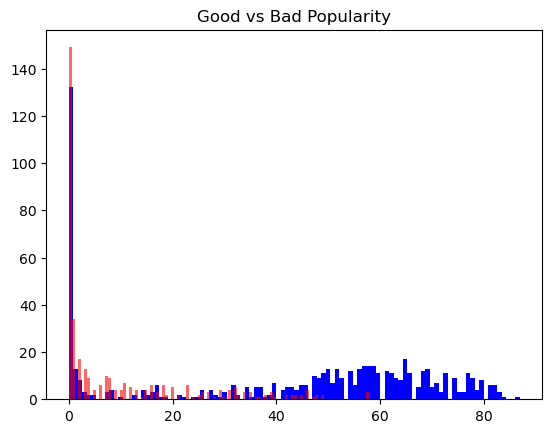

In [27]:
plt.hist(df_good['popularity'], color='b', bins=100)
plt.hist(df_bad['popularity'], alpha=0.6, color='r', bins=100)
plt.title('Good vs Bad Popularity')

### Duration ms

Text(0.5, 1.0, 'Good vs Bad Duration')

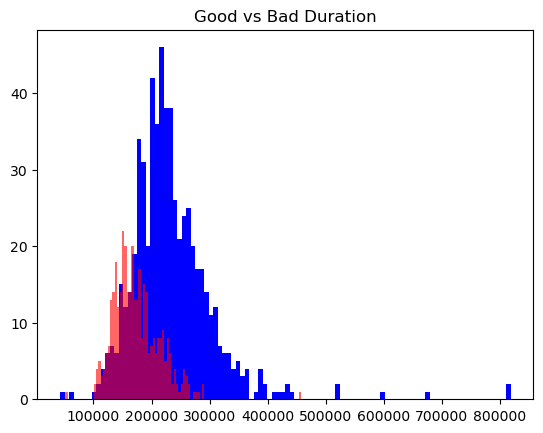

In [28]:
plt.hist(df_good['duration_ms'], color='b', bins=100)
plt.hist(df_bad['duration_ms'], alpha=0.6, color='r', bins=100)
plt.title('Good vs Bad Duration')

In [29]:
features = ['id', 'name', 'popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
good = df_good[features]
good

,id,name,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,1XNdu4czbxZ9tdVOhDtI4M,Cheia de Manias,51,0.707,0.614,7,-9.377,0,0.0580,0.1980,0.000000,0.1770,0.957,156.473
1,1SaeGiWS1LQhfRc6ObQfvq,Que Se Chama Amor,0,0.647,0.528,7,-12.739,1,0.0409,0.4110,0.000000,0.0481,0.621,136.118
2,6jBZxE0VZpmgZud4L5lo0u,Paparico,53,0.738,0.850,9,-7.278,1,0.0756,0.5300,0.000000,0.2130,0.967,88.799
3,43uHeQc9kdMzFAbxCTcgiI,Telegrama,54,0.517,0.516,11,-12.441,1,0.0342,0.4430,0.000004,0.2360,0.601,151.060
4,4tILvSk9XcdCBzjyzhsuze,É Tarde Demais,50,0.615,0.403,4,-11.648,1,0.0282,0.4250,0.000004,0.3210,0.454,136.377
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,429NtPmr12aypzFH3FkN9l,Coffee,69,0.532,0.137,9,-18.208,1,0.0717,0.9820,0.962000,0.1120,0.301,118.734
610,78oeeGkqmsr6r6AlW0x69d,Diamonds And Guns,49,0.582,0.925,7,-3.150,0,0.1820,0.0341,0.000116,0.5790,0.701,171.543
611,6PxC0ilHOSZGO6ASrktNv4,My Son John,49,0.828,0.506,5,-10.297,0,0.4850,0.8700,0.000000,0.3180,0.897,113.770
612,4Sope1x1EUQiWPyCMKFRRN,(Everything I Do) I Do It for You,47,0.576,0.175,0,-8.686,1,0.0368,0.8960,0.000000,0.0961,0.243,128.841


In [30]:
bad = df_bad[features]
bad

,id,name,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,76oTcfNSAGS1cmzVTjof5e,Sua filha é puta,28,0.684,0.443,5,-6.753,0,0.3230,0.49400,0.003050,0.0288,0.629,88.506
1,2kWowyDGD9yOL0WQzni20m,Vou Parar de Tomar Gin,0,0.802,0.520,0,-6.973,1,0.2530,0.44700,0.000000,0.0942,0.956,160.054
2,142YjJNOuXjzeSDnB1ujw1,Sua amiga deu,58,0.947,0.556,7,-4.536,1,0.0736,0.27700,0.000005,0.2080,0.426,130.046
3,0jlLqG8aydyDjZkJ0ShmPg,Capital das Notas,0,0.719,0.565,3,-5.924,1,0.2120,0.30900,0.000000,0.0768,0.643,82.732
4,5PNJXjGx8PAFooqCRuTUIv,Casal Bonnie e Clyde,49,0.552,0.491,1,-5.261,1,0.3120,0.07890,0.000000,0.0471,0.765,86.041
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
365,2QKYsuDCtjbzoBdaan7Ybd,Taca a xereca piranha,0,0.911,0.583,6,-4.517,0,0.1690,0.13900,0.000266,0.1700,0.593,131.008
366,4sDFmfir0mmHFeVgbg2WgR,Viagem,23,0.860,0.441,4,-8.664,1,0.0710,0.39300,0.000000,0.0647,0.566,132.188
367,3Z0kqYFQYF7KLli5gAMkf3,Toma Toma Toma,2,0.718,0.539,1,-3.643,1,0.2760,0.60000,0.000828,0.1560,0.619,130.088
368,4he5PH2421GeKAJ5a4Ftqu,Mamãe Quero Ir pra Gaiola,23,0.494,0.703,2,-6.214,1,0.4180,0.00664,0.000000,0.1180,0.851,183.801


In [31]:
corr_good = good.iloc[:, 2:].corr()
corr_good

,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
popularity,1.000000,0.061441,0.095695,0.001826,0.076119,0.034216,-0.029605,-0.162003,-0.047478,-0.078094,0.180993,-0.030273
danceability,0.061441,1.000000,-0.266839,-0.018598,-0.191108,0.070583,-0.086450,0.190291,-0.078334,-0.155815,0.437434,-0.238309
energy,0.095695,-0.266839,1.000000,-0.053154,0.760756,-0.163158,0.315703,-0.790312,-0.007397,0.076497,0.267039,0.156786
key,0.001826,-0.018598,-0.053154,1.000000,-0.064417,-0.078035,-0.038052,0.037374,-0.003852,-0.022849,0.018015,-0.034072
loudness,0.076119,-0.191108,0.760756,-0.064417,1.000000,-0.146149,0.194709,-0.603022,-0.109050,0.016748,0.123794,0.127585
mode,0.034216,0.070583,-0.163158,-0.078035,-0.146149,1.000000,-0.098902,0.139225,0.049077,-0.009046,0.043553,-0.013541
speechiness,-0.029605,-0.086450,0.315703,-0.038052,0.194709,-0.098902,1.000000,-0.181237,-0.033257,0.171439,0.048657,0.144792
acousticness,-0.162003,0.190291,-0.790312,0.037374,-0.603022,0.139225,-0.181237,1.000000,-0.014297,0.039051,-0.233677,-0.112999
instrumentalness,-0.047478,-0.078334,-0.007397,-0.003852,-0.109050,0.049077,-0.033257,-0.014297,1.000000,-0.048499,-0.058925,0.000045
liveness,-0.078094,-0.155815,0.076497,-0.022849,0.016748,-0.009046,0.171439,0.039051,-0.048499,1.000000,-0.104770,0.095043


In [32]:
corr_badd = bad.iloc[:, 2:].corr()
corr_badd

,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
popularity,1.000000,-0.114006,0.059579,0.090707,-0.005660,-0.164060,-0.055834,0.024742,-0.034914,-0.003889,0.018941,-0.075629
danceability,-0.114006,1.000000,-0.008288,-0.023167,0.098129,-0.007340,-0.187636,-0.001187,0.067465,-0.110284,0.175022,0.193261
energy,0.059579,-0.008288,1.000000,0.134526,0.556099,-0.050131,-0.055610,-0.084266,0.011207,0.228509,0.147833,0.162354
key,0.090707,-0.023167,0.134526,1.000000,0.042284,-0.183069,-0.047237,-0.037729,0.093360,0.139310,0.012930,0.010952
loudness,-0.005660,0.098129,0.556099,0.042284,1.000000,-0.041824,-0.248592,0.005485,0.029682,-0.019342,0.010970,0.115709
mode,-0.164060,-0.007340,-0.050131,-0.183069,-0.041824,1.000000,0.111018,0.007244,0.061745,0.005412,-0.065081,0.110751
speechiness,-0.055834,-0.187636,-0.055610,-0.047237,-0.248592,0.111018,1.000000,0.193628,-0.051022,0.126340,-0.088940,-0.136557
acousticness,0.024742,-0.001187,-0.084266,-0.037729,0.005485,0.007244,0.193628,1.000000,-0.004223,0.125175,-0.014948,-0.038790
instrumentalness,-0.034914,0.067465,0.011207,0.093360,0.029682,0.061745,-0.051022,-0.004223,1.000000,0.047606,0.058997,0.049445
liveness,-0.003889,-0.110284,0.228509,0.139310,-0.019342,0.005412,0.126340,0.125175,0.047606,1.000000,-0.134099,-0.048628
